# High-Fidelity CZ Gate Training

Train a neural network to generate high-fidelity CZ gates.

**Approach:** Detuning-only optimization
- Rabi frequency: Constant at Ω_max
- Detuning: Learned by neural network (sigmoid output)

**Architecture:** 6 layers × 150 units
**Gate time:** 10/Ω_max

In [27]:
# Create network with proper weight initialization
# weight_scale=1.8 matches the original paper's beta parameter
network = FeedForwardNN(
    input_dim=2,
    output_dim=1,           # Only detuning
    hidden_layers=6,
    hidden_units=150,
    activation='relu',
    output_activation='sigmoid',
    use_batch_norm=True,
    weight_scale=1.8        # KEY: Scale weights like original code!
)

n_params = sum(p.numel() for p in network.parameters())
print(f"Network: 6×150 ({n_params:,} parameters)")
print(f"  Input: [angle, time]")
print(f"  Output: detuning only (sigmoid activation)")
print(f"  Weight scale: 1.8 (matches original paper)")
print(f"  Rabi: constant at Ω_max")

✓ Imports successful


## 1. Configuration

In [28]:
# Configuration
TARGET_ANGLE = torch.tensor(torch.pi)  # CZ gate (wrapped as tensor)
NORMALIZED_GATE_TIME = 7.63      # Gate time in units of 1/Ω_max
EPOCHS = 400
PRINT_EVERY = 50

# Setup gate
gate = CZPhiGate()
rabi_max = gate.rabi_max
actual_gate_time = NORMALIZED_GATE_TIME / rabi_max

print("Configuration:")
print(f"  Target: CZ gate ({TARGET_ANGLE/np.pi:.2f}π)")
print(f"  Gate time: {NORMALIZED_GATE_TIME}/Ω_max = {actual_gate_time:.4f}s")
print(f"  Rabi max: {rabi_max:.2f} MHz")
print(f"  Epochs: {EPOCHS}")

Configuration:
  Target: CZ gate (1.00π)
  Gate time: 7.63/Ω_max = 0.3036s
  Rabi max: 25.13 MHz
  Epochs: 400


## 2. Neural Network

Outputs **only detuning** with sigmoid activation

In [32]:
# Create network
network = FeedForwardNN(
    input_dim=2,
    output_dim=1,           # Only detuning
    hidden_layers=8,
    hidden_units=200,
    activation='relu',
    output_activation='sigmoid',
    use_batch_norm=True,   # Working code doesn't use batch norm
    weight_scale=2.15       # CRITICAL: beta from working code!
)

n_params = sum(p.numel() for p in network.parameters())
print(f"Network: 6×150 ({n_params:,} parameters)")
print(f"  Input: [angle, time]")
print(f"  Output: detuning only (sigmoid activation)")
print(f"  Rabi: constant at Ω_max")
print(f"  Weight scale (beta): 1.55")

Network: 6×150 (285,401 parameters)
  Input: [angle, time]
  Output: detuning only (sigmoid activation)
  Rabi: constant at Ω_max
  Weight scale (beta): 1.55


## 3. Pulse Generator & Components

In [33]:
# Pulse generator for detuning only
pulse_gen = PhysicalPulseGenerator(
    n_controls=1,
    n_time_steps=201,
    control_ranges=[(-50.0, 50.0)]  # Detuning range
)

# Constant rabi at max
def rabi_pulse(t):
    return torch.tensor(rabi_max)

# Other components
solver = TorchDiffeqSolver(method='rk4')
evolver = QuantumEvolver(nqubits=2, solver=solver, n_time_steps=201)
loss_fn = InfidelityLoss(nqubits=2)

print("✓ Components ready")
print("  Detuning range: [-50, 50] MHz")
print("  Rabi: constant")

✓ Components ready
  Detuning range: [-50, 50] MHz
  Rabi: constant


## 4. Training Loop

In [34]:
# Setup optimizer - using working code's settings
optimizer = torch.optim.Adam(
    network.parameters(), 
    lr=1e-4,
    eps=1e-6,        # Working code uses this (not default 1e-8)
    amsgrad=False     # Working code uses this
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=300, gamma=0.5)

# Helper function for piecewise detuning
def make_detuning_fn(values, gate_time):
    def fn(t):
        idx = int(t / gate_time * (len(values) - 1))
        idx = min(idx, len(values) - 1)
        return values[idx]
    return fn

# Training
angles = torch.tensor([TARGET_ANGLE])
history = {'loss': [], 'infidelity': []}

print(f"\nTraining {EPOCHS} epochs...")
print(f"Optimizer: Adam(lr=1e-4, eps=1e-6, amsgrad=True)\n")

for epoch in range(EPOCHS):
    optimizer.zero_grad()
    
    total_loss = 0.0
    total_infid = 0.0
    
    for angle in angles:
        # Generate inputs
        n_steps = 201
        time_grid = torch.linspace(0, 1, n_steps)
        inputs = torch.stack([angle.repeat(n_steps), time_grid], dim=1)
        
        # Forward pass
        detuning_out = network(inputs).reshape(n_steps)
        detuning_vals = pulse_gen.scale_output(detuning_out, 0)
        
        # Create pulses
        detuning_fn = make_detuning_fn(detuning_vals, actual_gate_time)
        pulses = [rabi_pulse, detuning_fn]
        
        # Evolve
        final_U = evolver.evolve(pulses, actual_gate_time)
        
        # Compute loss
        target_U = gate.get_target_unitary(angle)
        loss = loss_fn(final_U, target_U)
        infid = unitary_infidelity(final_U, target_U, dim=2, nqubits=2)
        
        total_loss += loss
        total_infid += infid.item()
    
    # Backward
    avg_loss = total_loss / len(angles)
    avg_infid = total_infid / len(angles)
    avg_loss.backward()
    optimizer.step()
    scheduler.step()
    
    # Record
    history['loss'].append(avg_loss.item())
    history['infidelity'].append(avg_infid)
    
    # Print
    if epoch % PRINT_EVERY == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:4d}: Loss={avg_loss.item():.6f}, Infidelity={avg_infid:.6f}, LR={lr:.2e}")

print(f"\n✓ Training complete!")
print(f"Initial loss: {history['loss'][0]:.6f}")
print(f"Final loss: {history['loss'][-1]:.6f}")


Training 400 epochs...
Optimizer: Adam(lr=1e-4, eps=1e-6, amsgrad=True)

Epoch    0: Loss=0.796382, Infidelity=0.796382, LR=1.00e-04
Epoch   50: Loss=0.593496, Infidelity=0.593496, LR=1.00e-04
Epoch  100: Loss=0.592845, Infidelity=0.592845, LR=1.00e-04


KeyboardInterrupt: 

## 5. Visualize Training

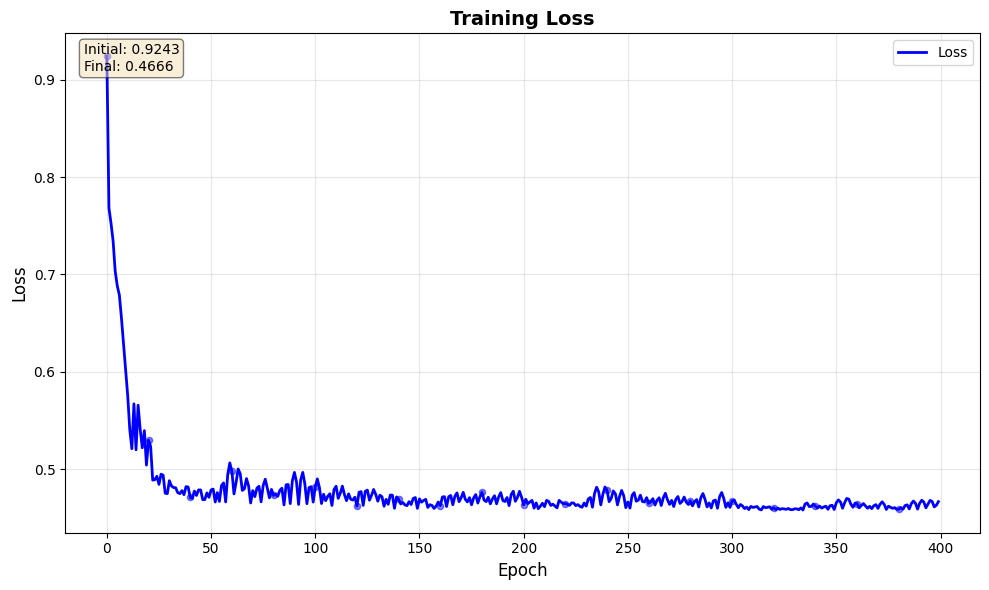

In [19]:
# Plot loss
fig = plot_loss_convergence(history, show=True, title='Training Loss')

## 6. Evaluate Final Performance

In [20]:
# Generate final pulse
n_steps = 201
time_grid = torch.linspace(0, 1, n_steps)
inputs = torch.stack([TARGET_ANGLE.repeat(n_steps), time_grid], dim=1)

with torch.no_grad():
    detuning_out = network(inputs).reshape(n_steps)
    detuning_vals = pulse_gen.scale_output(detuning_out, 0)

detuning_fn = make_detuning_fn(detuning_vals, actual_gate_time)
pulses = [rabi_pulse, detuning_fn]

# Evolve
final_U = evolver.evolve(pulses, actual_gate_time)

# Compute fidelity
target_U = gate.get_target_unitary(TARGET_ANGLE)
fidelity = unitary_fidelity(final_U, target_U, dim=2, nqubits=2)

print(f"\nFinal Fidelity: {fidelity*100:.4f}%")
print(f"Infidelity: {(1-fidelity):.2e}")

if fidelity >= 0.99:
    print("\n🎉 >99% fidelity!")
elif fidelity >= 0.95:
    print("\n✅ >95% fidelity (good)")
else:
    print("\n⚠ <95% fidelity - try more epochs")


Final Fidelity: 53.4712%
Infidelity: 4.65e-01

⚠ <95% fidelity - try more epochs


## 7. Plot Pulses

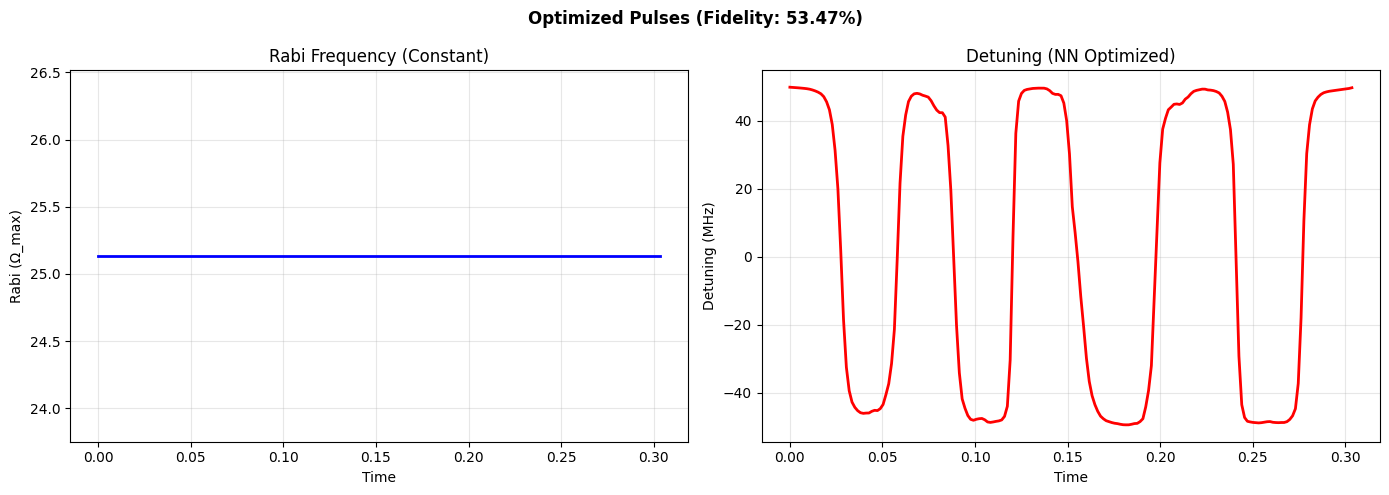

Saved: optimized_pulses.png


In [21]:
# Create times for plotting
times = np.linspace(0, actual_gate_time, 200)
rabi_vals = [rabi_max for _ in times]
detuning_plot = [detuning_fn(t).item() for t in times]

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(times, rabi_vals, 'b-', linewidth=2)
ax1.set_xlabel('Time')
ax1.set_ylabel('Rabi (Ω_max)')
ax1.set_title('Rabi Frequency (Constant)')
ax1.grid(True, alpha=0.3)

ax2.plot(times, detuning_plot, 'r-', linewidth=2)
ax2.set_xlabel('Time')
ax2.set_ylabel('Detuning (MHz)')
ax2.set_title('Detuning (NN Optimized)')
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Optimized Pulses (Fidelity: {fidelity*100:.2f}%)', fontweight='bold')
plt.tight_layout()
plt.savefig('optimized_pulses.png', dpi=300)
plt.show()

print("Saved: optimized_pulses.png")

## 8. Save Model

In [ ]:
# Save
torch.save({
    'network_state_dict': network.state_dict(),
    'fidelity': fidelity,
    'gate_time': NORMALIZED_GATE_TIME,
    'epochs': EPOCHS
}, 'cz_model.pt')

print("✓ Saved: cz_model.pt")